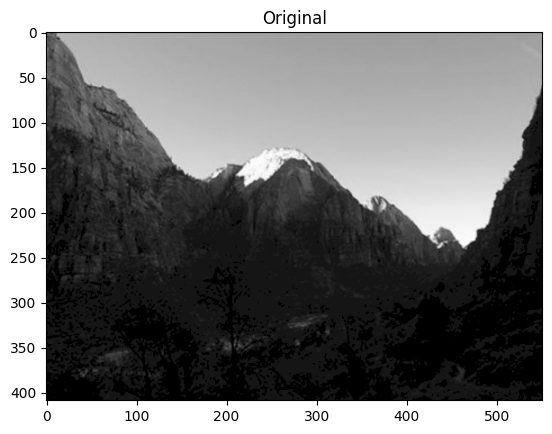

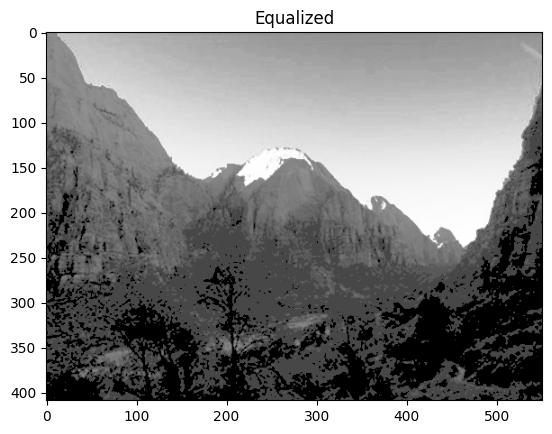

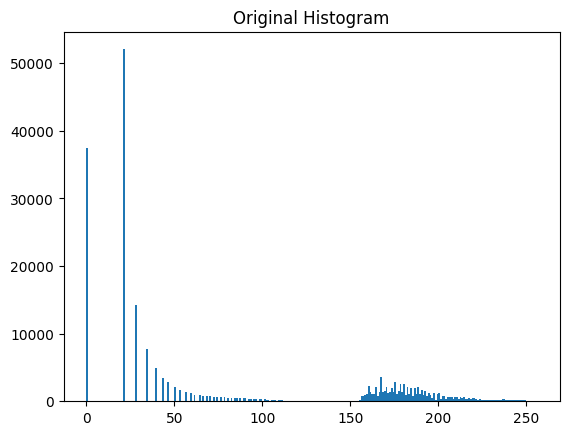

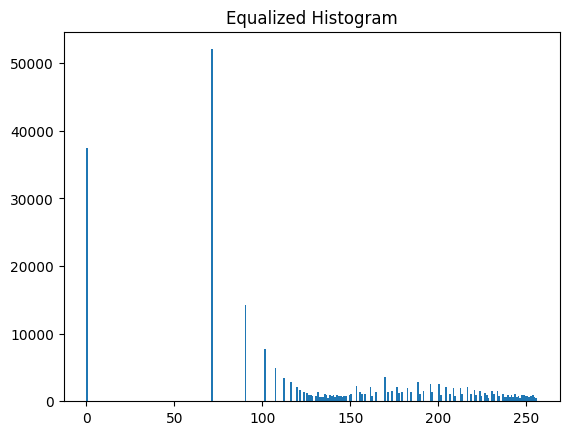

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def load_gray(path):
    return cv2.imread(path, cv2.IMREAD_GRAYSCALE)


def equalize_histogram(image):
    return cv2.equalizeHist(image)


def show_histogram(image, title):
    plt.figure()
    plt.hist(image.ravel(), bins=256, range=[0, 256])
    plt.title(title)
    plt.show()


def task1(image_path):
    image = load_gray(image_path)
    equalized = equalize_histogram(image)

    plt.imshow(image, cmap='gray')
    plt.title("Original")
    plt.show()

    plt.imshow(equalized, cmap='gray')
    plt.title("Equalized")
    plt.show()

    show_histogram(image, "Original Histogram")
    show_histogram(equalized, "Equalized Histogram")


task1("lab_images/1.png")

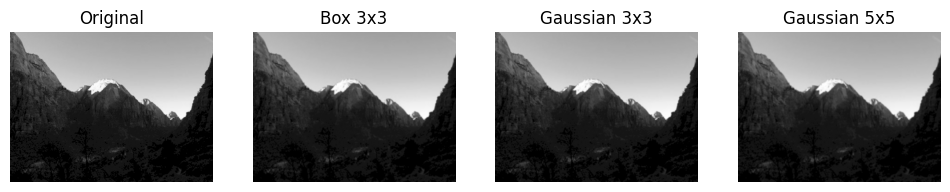

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def box_filter(image, ksize):
    return cv2.blur(image, (ksize, ksize))


def gaussian_filter(image, ksize, sigma):
    return cv2.GaussianBlur(image, (ksize, ksize), sigma)


def display_images(images, titles):
    plt.figure(figsize=(12, 6))
    for i in range(len(images)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()


def task2(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    box3 = box_filter(image, 3)
    gauss3 = gaussian_filter(image, 3, 0)
    gauss5 = gaussian_filter(image, 5, 0)

    display_images(
        [image, box3, gauss3, gauss5],
        ["Original", "Box 3x3", "Gaussian 3x3", "Gaussian 5x5"]
    )

task2("lab_images/1.png")

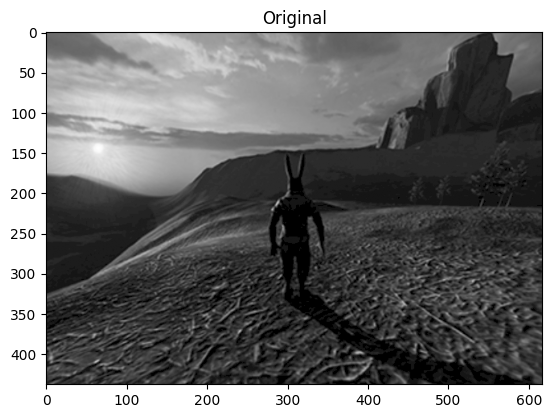

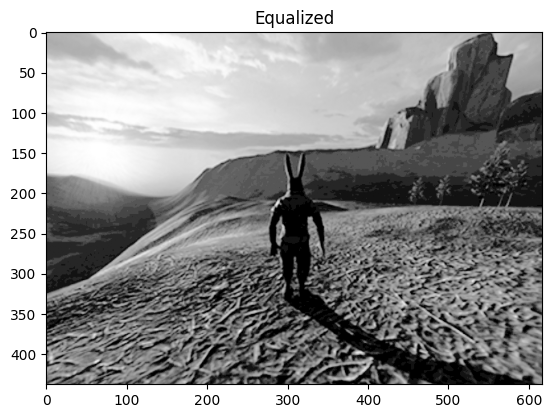

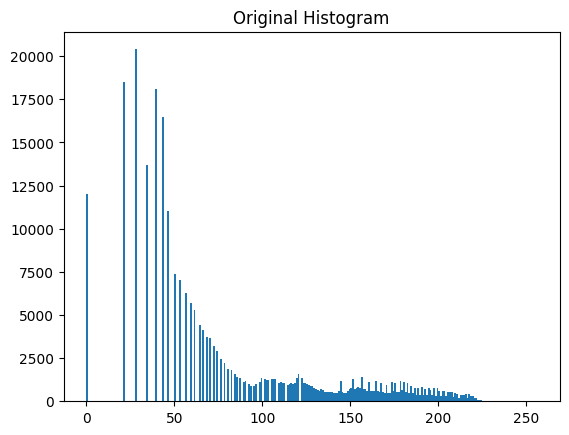

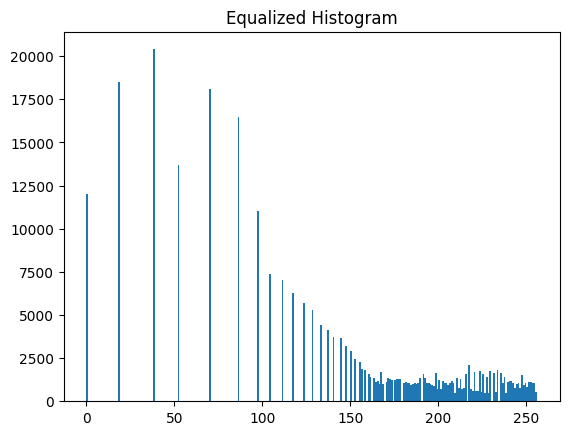

In [3]:
import cv2
import matplotlib.pyplot as plt


def unsharp_mask(image, blur_ksize=9, sigma=10, alpha=1.5, beta=-0.5):
    blurred = cv2.GaussianBlur(image, (blur_ksize, blur_ksize), sigma)
    sharpened = cv2.addWeighted(image, alpha, blurred, beta, 0)
    return sharpened


def task3(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    sharp = unsharp_mask(image)

    plt.imshow(sharp, cmap='gray')
    plt.title("Unsharp Masking")
    plt.show()

task1("lab_images/3.png")

In [ ]:
import cv2
import numpy as np


def box_kernel(n):
    return np.ones((n, n), np.float32) / (n * n)


def apply_convolution(image, kernel):
    return cv2.filter2D(image, -1, kernel)


def manual_unsharp(image, filt_size, k):
    kernel = box_kernel(filt_size)
    blurred = apply_convolution(image, kernel)
    diff = image - blurred
    sharp = image + k * diff
    return sharp


def task4(image_path, filt_size, k):
    image = cv2.imread(image_path, 0).astype('float32') / 255
    result = manual_unsharp(image, filt_size, k)

    cv2.imshow("Sharpened", result)
    cv2.waitKey(0)
    cv2.destroyAllWindows()




2026-03-03 10:35:25.857 python[87361:5919601] +[IMKClient subclass]: chose IMKClient_Legacy
2026-03-03 10:35:25.857 python[87361:5919601] +[IMKInputSession subclass]: chose IMKInputSession_Legacy
